## Problem Definition

####  Driver drowsiness contributes to road accidents and delayed reaction times.

####  The objective of this project is to detect eye closure using deep learning and provide real-time monitoring through webcam integration.

####  This system aims to classify eye state as :
####  - Open
#### - Closed

####  and demonstrate a foundation for drowsiness alert systems.

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization 
from tensorflow.keras.callbacks import ReduceLROnPlateau

import matplotlib.pyplot as plt
import numpy as np
import os

## Data Preprocessing

In [3]:


train_closed = len(os.listdir("dataset/train/closed"))
train_open = len(os.listdir("dataset/train/open"))

val_closed = len(os.listdir("dataset/validate/closed"))
val_open = len(os.listdir("dataset/validate/open"))

test_closed = len(os.listdir("dataset/test/closed"))
test_open = len(os.listdir("dataset/test/open"))

print("TRAIN")
print("Closed:", train_closed)
print("Open:", train_open)

print("\nVALIDATION")
print("Closed:", val_closed)
print("Open:", val_open)

print("\nTEST")
print("Closed:", test_closed)
print("Open:", test_open)

TRAIN
Closed: 9636
Open: 9642

VALIDATION
Closed: 3024
Open: 2400

TEST
Closed: 2508
Open: 2784


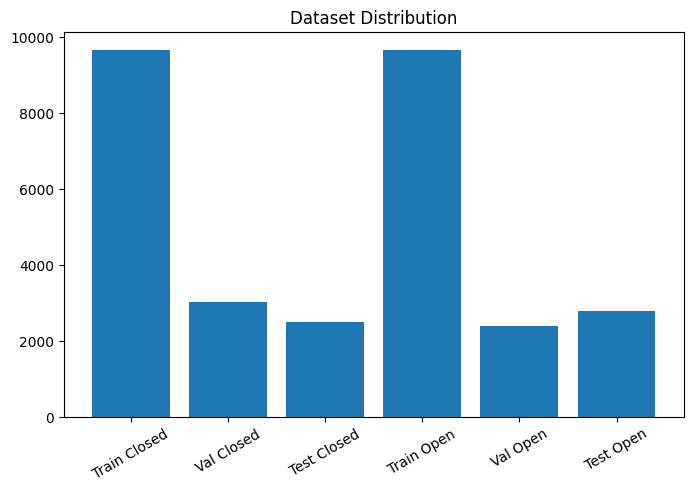

In [4]:


labels = ["Closed","Open"]
counts = [train_closed,val_closed,test_closed,
          train_open,val_open,test_open]

plt.figure(figsize=(8,5))

plt.bar(
    [
        "Train Closed",
        "Val Closed",
        "Test Closed",
        "Train Open",
        "Val Open",
        "Test Open"
    ],
    counts
)

plt.xticks(rotation=30)

plt.title("Dataset Distribution")

plt.show()

In [5]:
from sklearn.utils.class_weight import compute_class_weight


In [6]:
train_dir = "dataset/train"
val_dir = "dataset/validate"
test_dir = "dataset/test"

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [8]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    horizontal_flip=True,

    rotation_range=15,

    width_shift_range=0.15,
    height_shift_range=0.15,

    zoom_range=0.2,

    brightness_range=[0.4,1.6],

    shear_range=0.1,

    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
print(train_generator.class_indices)

Found 19278 images belonging to 2 classes.
Found 5424 images belonging to 2 classes.
Found 5292 images belonging to 2 classes.
{'closed': 0, 'open': 1}


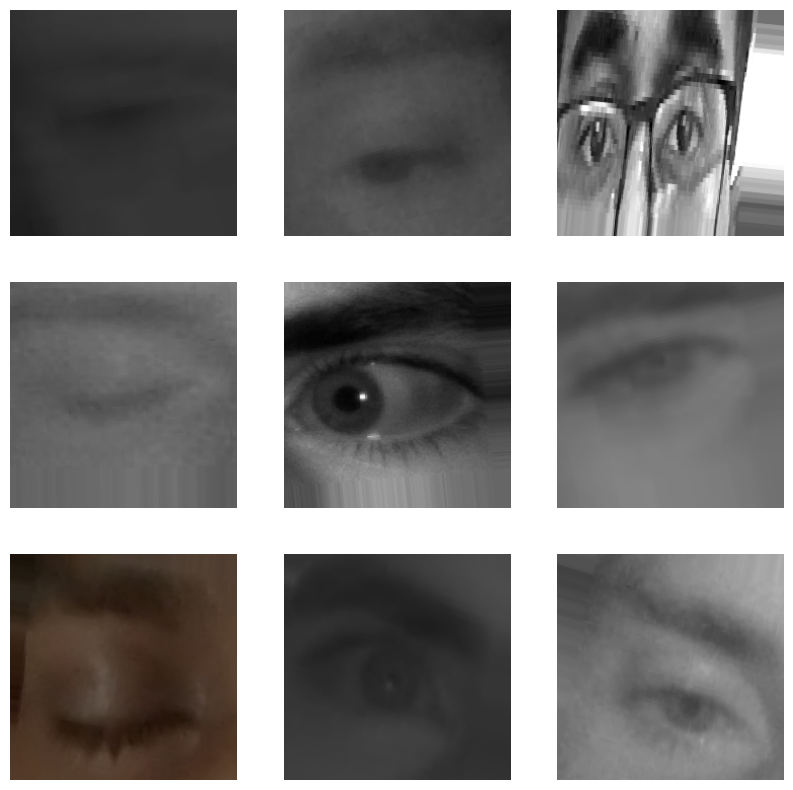

In [10]:
sample_batch = next(train_generator)

images = sample_batch[0]

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

## Model Building

In [11]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: 1.0003113325031132, 1: 0.9996888612321095}


In [12]:
images, labels = next(train_generator)

print(images.shape)
print(labels[:10])

(32, 224, 224, 3)
[0. 1. 0. 0. 1. 0. 0. 1. 1. 1.]


In [13]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [14]:
base_model.trainable = True

In [15]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [16]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),
    
    BatchNormalization(),

    Dropout(0.6),

    Dense(1, activation='sigmoid')
])

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.000001
)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Training

In [20]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stop,reduce_lr],
    class_weight=class_weights
)

Epoch 1/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 720s 1s/step - accuracy: 0.7751 - loss: 0.5203 - val_accuracy: 0.8606 - val_loss: 0.3236 - learning_rate: 1.0000e-05
Epoch 2/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 554s 918ms/step - accuracy: 0.8564 - loss: 0.3533 - val_accuracy: 0.9165 - val_loss: 0.2257 - learning_rate: 1.0000e-05
Epoch 3/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 550s 912ms/step - accuracy: 0.8884 - loss: 0.2848 - val_accuracy: 0.9154 - val_loss: 0.2183 - learning_rate: 1.0000e-05
Epoch 4/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 548s 909ms/step - accuracy: 0.9046 - loss: 0.2375 - val_accuracy: 0.9130 - val_loss: 0.2275 - learning_rate: 1.0000e-05
Epoch 5/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 551s 914ms/step - accuracy: 0.9144 - loss: 0.2177 - val_accuracy: 0.8980 - val_loss: 0.2652 - learning_rate: 1.0000e-05
Epoch 6/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 546s 906ms/step - accuracy: 0.9202 - loss: 0.2076 - val_accuracy: 0.8999 - val_loss: 0.2604 - learning_rate: 2.0000e-06


## Evaluation

In [51]:
loss,accuracy=model.evaluate(test_generator)
print(accuracy)

166/166 ━━━━━━━━━━━━━━━━━━━━ 86s 520ms/step - accuracy: 0.9208 - loss: 0.1798
0.920823872089386


In [21]:
import pandas as pd

pd.DataFrame(
    history.history
).to_csv(
    "history_v1.csv",
    index=False
)

In [22]:
y_true = test_generator.classes

print(y_true[:10])

test_generator.reset()

y_prob = model.predict(test_generator)

[0 0 0 0 0 0 0 0 0 0]
166/166 ━━━━━━━━━━━━━━━━━━━━ 88s 522ms/step


In [24]:
# Predict probabilities
y_prob = model.predict(test_generator)

# Convert to classes
y_pred = (y_prob > 0.5).astype(int)

# Flatten
y_pred = y_pred.flatten()

# Actual labels
y_true = test_generator.classes

# Report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Closed",
            "Open"
        ]
    )
)

166/166 ━━━━━━━━━━━━━━━━━━━━ 91s 550ms/step
              precision    recall  f1-score   support

      Closed       0.88      0.97      0.92      2508
        Open       0.97      0.88      0.92      2784

    accuracy                           0.92      5292
   macro avg       0.92      0.92      0.92      5292
weighted avg       0.93      0.92      0.92      5292



In [25]:
from tensorflow.keras.callbacks import CSVLogger

csv_logger = CSVLogger(
    "training_log.csv"
)

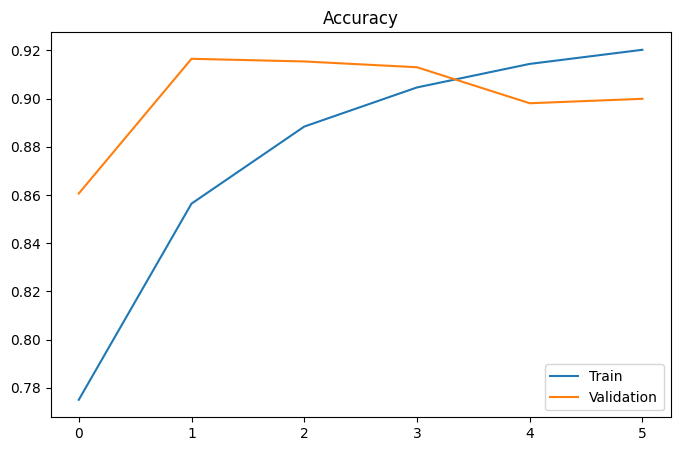

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.title("Accuracy")

plt.show()

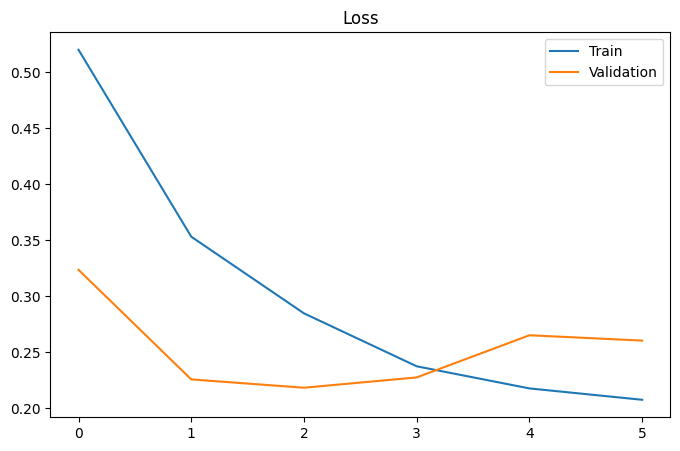

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.title("Loss")

plt.show()

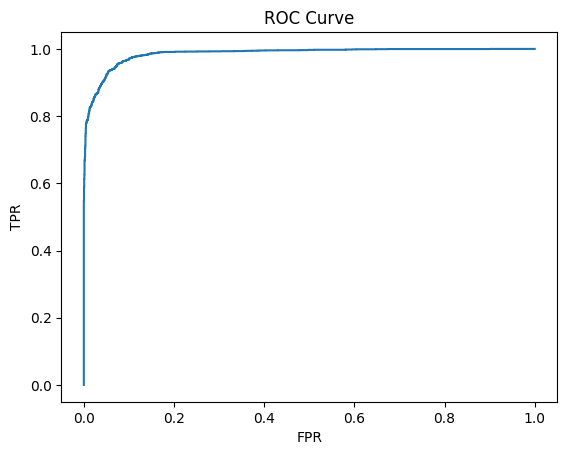

In [29]:
from sklearn.metrics import roc_curve

fpr,tpr,_=roc_curve(y_true,y_prob)

plt.plot(fpr,tpr)

plt.xlabel("FPR")

plt.ylabel("TPR")

plt.title("ROC Curve")

plt.show()

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,916,805 (18.76 MB)

 Trainable params: 1,288,257 (4.91 MB)

 Non-trainable params: 1,052,032 (4.01 MB)

 Optimizer params: 2,576,516 (9.83 MB)

In [31]:
model.save("models/drowsiness_modelretrained.keras")

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[2427   81]
 [ 338 2446]]


<Axes: >

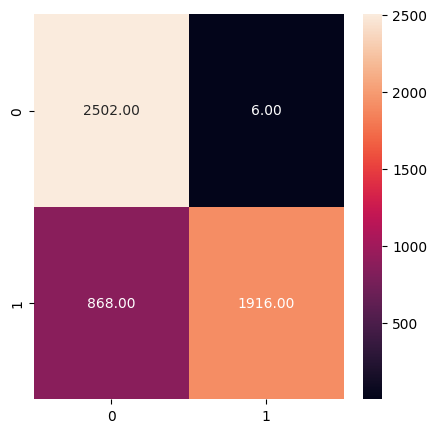

In [ ]:
import seaborn as sns
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True,fmt='.2f')

In [ ]:
import os

closed_count = len(os.listdir("D:/DS/Project/Deep_learning_project/Drowsiness detection/dataset/train/closed"))
open_count = len(os.listdir("D:/DS/Project/Deep_learning_project/Drowsiness detection/dataset/train/open"))

print("Closed:", closed_count)
print("Open:", open_count)

Closed: 9636
Open: 9642


In [ ]:
y_prob = model.predict(test_generator)

print("Min:", y_prob.min())
print("Max:", y_prob.max())
print("Mean:", y_prob.mean())

166/166 ━━━━━━━━━━━━━━━━━━━━ 93s 560ms/step
Min: 1.9835468e-06
Max: 0.9999996
Mean: 0.35814428


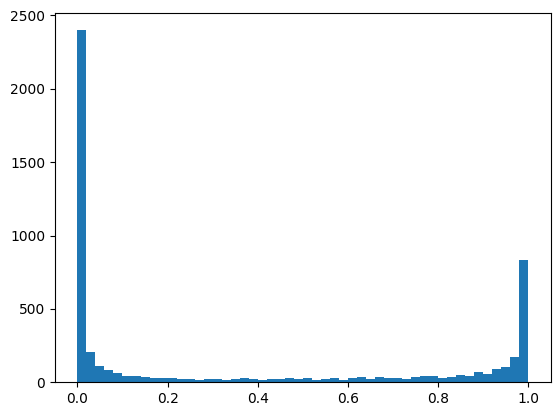

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=50)
plt.show()

In [ ]:
import numpy as np

closed_probs = y_prob[y_true == 0]
open_probs = y_prob[y_true == 1]

print("Closed mean:", np.mean(closed_probs))
print("Open mean:", np.mean(open_probs))

Closed mean: 0.009577977
Open mean: 0.6721545


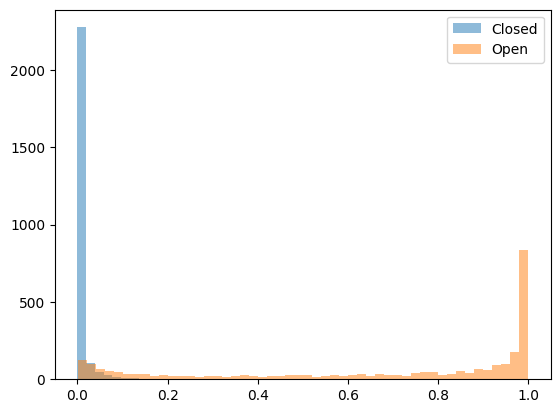

In [ ]:
import matplotlib.pyplot as plt

closed_probs = y_prob[y_true == 0]
open_probs = y_prob[y_true == 1]

plt.hist(closed_probs, bins=50, alpha=0.5, label="Closed")
plt.hist(open_probs, bins=50, alpha=0.5, label="Open")

plt.legend()
plt.show()

In [39]:
for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    preds = (y_prob > threshold).astype(int)

    from sklearn.metrics import classification_report

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_true, preds))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2508
           1       0.97      0.88      0.92      2784

    accuracy                           0.92      5292
   macro avg       0.92      0.92      0.92      5292
weighted avg       0.93      0.92      0.92      5292


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      2508
           1       0.98      0.85      0.91      2784

    accuracy                           0.91      5292
   macro avg       0.91      0.91      0.91      5292
weighted avg       0.92      0.91      0.91      5292


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.82      0.99      0.90      2508
           1       0.99      0.81      0.89      2784

    accuracy                           0.89      5292
   macro avg       0.91      0.90      0.89      5292
weighted avg       0.91   

## Model Comparison

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam



In [41]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

])

C:\Users\amarn\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
cnn_model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [43]:
from tensorflow.keras.callbacks import (
    EarlyStopping
)

early_stop = EarlyStopping(

    patience=3,

    restore_best_weights=True
)



In [44]:
cnn_history = cnn_model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=5,

    callbacks=[early_stop],

    class_weight=class_weights
)

Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 622s 1s/step - accuracy: 0.6822 - loss: 0.6020 - val_accuracy: 0.6661 - val_loss: 0.6062
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 937s 2s/step - accuracy: 0.7561 - loss: 0.5004 - val_accuracy: 0.8191 - val_loss: 0.4943
Epoch 3/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 893s 1s/step - accuracy: 0.7960 - loss: 0.4425 - val_accuracy: 0.8527 - val_loss: 0.3666
Epoch 4/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 761s 1s/step - accuracy: 0.8131 - loss: 0.4125 - val_accuracy: 0.8768 - val_loss: 0.3392
Epoch 5/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 571s 946ms/step - accuracy: 0.8316 - loss: 0.3859 - val_accuracy: 0.8481 - val_loss: 0.3444


In [52]:
cnn_model.save("models/CNN_model.keras")

In [45]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    test_generator
)

print(
    "CNN Accuracy:",
    cnn_acc
)

166/166 ━━━━━━━━━━━━━━━━━━━━ 97s 587ms/step - accuracy: 0.9150 - loss: 0.2528
CNN Accuracy: 0.9149659872055054


In [46]:
from sklearn.metrics import (
    classification_report
)

y_prob = cnn_model.predict(
    test_generator
)

y_pred = (
    y_prob > 0.5
).astype(int)

print(

classification_report(
    y_true,
    y_pred,
    target_names=[
        "Closed",
        "Open"
    ]
)

)

166/166 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step
              precision    recall  f1-score   support

      Closed       0.95      0.86      0.91      2508
        Open       0.89      0.96      0.92      2784

    accuracy                           0.91      5292
   macro avg       0.92      0.91      0.91      5292
weighted avg       0.92      0.91      0.91      5292



In [ ]:
import pandas as pd

comparison = pd.DataFrame({

"Model":[
"CNN",
"MobileNetV2"],

"Accuracy":[
cnn_acc,
0.94],

"Precision":[
0.92,
0.94],

"Recall":[
0.91,
0.94],

"F1":[
0.91,
0.94]

})

print(
comparison
)

         Model  Accuracy  Precision  Recall    F1
0          CNN  0.914966       0.92    0.91  0.91
1  MobileNetV2  0.940000       0.94    0.94  0.94
